# HMM vs reciprocal-BLAST (RBH) ortholog calls

Compares the hmmsearch results (`results/raw/*.tblout`, from 05_search_genomes.py) with the
reciprocal DIAMOND hits in `../RBH/results/diamond_reverseBLAST_streptomycetae/reciprocal/reciprocal_hits.tsv`.

**RBH is used as the reference here.** Note it is not a perfect truth set: the forward search
required >= 65 % identity and >= 70 % query/subject coverage, so very distant orthologs can be
missing from RBH too. "HMM only" calls are therefore not automatically false.

Only genes present in both analyses are compared (SCO2401, SCO2402, SCO2407, SCO2439, SCO2440).
SCO2408 has no RBH run; SCO2403 and the vnz genes have no HMM.

For every (genome, gene) pair, the HMM call is the **best-scoring HMM hit** in that genome, kept or rejected
by a cutoff rule. Each pair then falls into one category:

| category | meaning |
|---|---|
| `agree: same protein` | both call an ortholog, and it is the same protein |
| `agree: absent` | neither calls an ortholog |
| `both, different protein` | both call one, but the HMM best hit is not the RBH protein |
| `HMM only` | HMM calls an ortholog, RBH does not |
| `RBH only` | RBH calls an ortholog, HMM does not |

In [1]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = "/vol/local/calarass/Projects/ara_comp_genomics"
HMM_RAW_DIR = f"{PROJECT_DIR}/hmm_search/results/raw/Streptomycetae"
SELF_HIT_FILE = f"{PROJECT_DIR}/hmm_search/results/summary/self_hit_check.tsv"
RBH_FILE = f"{PROJECT_DIR}/RBH/results/diamond_reverseBLAST_streptomycetae/reciprocal/reciprocal_hits.tsv"
OUT_FILE = f"{PROJECT_DIR}/hmm_search/results/summary/hmm_vs_rbh_calls.tsv"

# the cutoff you want to test
E_CUTOFF = 1e-100

# hmmsearch prints E = 0 when it underflows; treat it as this for -log10(E)
E_FLOOR = 1e-300

# chart colours
C_RBH = "#2a78d6"      # RBH ortholog
C_NOT_RBH = "#a3a29b"  # not an RBH ortholog
C_PRECISION = "#2a78d6"
C_RECALL = "#eb6834"

## 1. Load the HMM hits

In [2]:
def protein_key(seq_id):
    # 'Genome|LOCUS_TAG|description|...' -> 'Genome|LOCUS_TAG' (same format in both analyses).
    # Square brackets are dropped: HMM has '[Kitasatospora]_papulosa', RBH 'Kitasatospora_papulosa'
    return "|".join(seq_id.split("|")[:2]).replace("[", "").replace("]", "")


def gene_of(name):
    m = re.search(r"SCO\d+", name)
    return m.group(0) if m else None


rows = []
for path in sorted(glob.glob(f"{HMM_RAW_DIR}/*.tblout")):
    with open(path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.split()
            if len(fields) < 6:
                continue
            rows.append((fields[0], fields[2], float(fields[4]), float(fields[5])))

hmm = pd.DataFrame(rows, columns=["target", "model", "evalue", "bitscore"])
hmm["gene"] = hmm.model.map(gene_of)
hmm["protein"] = hmm.target.map(protein_key)
hmm["genome"] = hmm.protein.str.split("|", regex=False).str[0]
hmm["neglog10_e"] = -np.log10(hmm.evalue.clip(lower=E_FLOOR))

# rank of each hit within (genome, gene): 1 = best
hmm = hmm.sort_values("bitscore", ascending=False)
hmm["rank"] = hmm.groupby(["genome", "gene"]).cumcount() + 1

print(f"{len(hmm)} HMM hits, {hmm.genome.nunique()} genomes, models: {sorted(hmm.model.unique())}")
print(f"E-values reported as 0 (set to {E_FLOOR:g}): {(hmm.evalue == 0).sum()}")

14187 HMM hits, 207 genomes, models: ['Conserved-SCO2407', 'Conserved-SCO2408', 'Conserved_SCO2401', 'Conserved_SCO2402', 'Conserved_SCO2439', 'Conserved_SCO2440']
E-values reported as 0 (set to 1e-300): 11


## 2. Load the RBH hits and the current `min_bitscore` thresholds

In [3]:
rbh = pd.read_csv(RBH_FILE, sep="\t")
rbh["gene"] = rbh.qseqid.map(gene_of)
rbh["protein"] = rbh.sseqid.map(protein_key)
rbh["genome"] = rbh.protein.str.split("|", regex=False).str[0]

GENES = sorted(set(hmm.gene.dropna()) & set(rbh.gene.dropna()))
print("Genes compared:", GENES)
print("HMM only (not compared):", sorted(set(hmm.gene.dropna()) - set(GENES)))
print("RBH only (not compared):", sorted(set(rbh.qseqid) - set(rbh[rbh.gene.isin(GENES)].qseqid)))

rbh = rbh[rbh.gene.isin(GENES)]
missing_genomes = sorted(set(rbh.genome) - set(hmm.genome))
if missing_genomes:
    print("WARNING: RBH genomes not found in the HMM results (name mismatch?):", missing_genomes)

# one genome can have >1 RBH protein (in-paralogs): keep them all as a set
rbh_sets = rbh.groupby(["genome", "gene"]).protein.agg(set)

self_hit = pd.read_csv(SELF_HIT_FILE, sep="\t", na_values="NA")
self_hit["gene"] = self_hit.gene.map(gene_of)
MIN_BITSCORE = self_hit.set_index("gene").min_bitscore.to_dict()
print("min_bitscore:", {g: MIN_BITSCORE.get(g) for g in GENES})

Genes compared: ['SCO2401', 'SCO2402', 'SCO2407', 'SCO2439', 'SCO2440']
HMM only (not compared): ['SCO2408']
RBH only (not compared): ['SCO2403', 'vnz_33170-lacI', 'vnz_33175-araB', 'vnz_33180-araA', 'vnz_33185-araD']
min_bitscore: {'SCO2401': 650.2, 'SCO2402': 535.2, 'SCO2407': 623.8, 'SCO2439': 506.8, 'SCO2440': 401.5}


## 3. One row per (genome, gene)

`hmm_best_*` = best HMM hit in that genome. `rbh_hmm_rank` = where the RBH protein sits in the HMM ranking
for that genome (1 = the HMM also ranks it first; NaN = no RBH ortholog).

In [4]:
genomes = sorted(hmm.genome.unique())
calls = pd.MultiIndex.from_product([genomes, GENES], names=["genome", "gene"]).to_frame(index=False)

best = (hmm[hmm.gene.isin(GENES) & (hmm["rank"] == 1)]
        .set_index(["genome", "gene"])[["protein", "bitscore", "evalue", "neglog10_e"]]
        .add_prefix("hmm_best_"))
calls = calls.join(best, on=["genome", "gene"])

calls["rbh_proteins"] = [rbh_sets.get((g, gene), set()) for g, gene in zip(calls.genome, calls.gene)]
calls["rbh"] = calls.rbh_proteins.map(bool)

# score and rank the HMM gave to the RBH protein
hmm_idx = hmm.set_index(["genome", "gene", "protein"])[["bitscore", "evalue", "rank"]]
def rbh_protein_stats(row):
    hits = [hmm_idx.loc[(row.genome, row.gene, p)] for p in row.rbh_proteins
            if (row.genome, row.gene, p) in hmm_idx.index]
    if not hits:
        return pd.Series({"rbh_hmm_bitscore": np.nan, "rbh_hmm_evalue": np.nan, "rbh_hmm_rank": np.nan})
    top = max(hits, key=lambda h: h.bitscore)
    return pd.Series({"rbh_hmm_bitscore": top.bitscore, "rbh_hmm_evalue": top.evalue, "rbh_hmm_rank": top["rank"]})

calls = calls.join(calls.apply(rbh_protein_stats, axis=1))
calls["same_protein"] = [p in s for p, s in zip(calls.hmm_best_protein, calls.rbh_proteins)]

print("RBH orthologs that the HMM also ranks #1 in that genome:")
print(calls[calls.rbh].groupby("gene").rbh_hmm_rank.apply(lambda r: f"{(r == 1).sum()} / {len(r)}"))

RBH orthologs that the HMM also ranks #1 in that genome:
gene
SCO2401    130 / 130
SCO2402      94 / 94
SCO2407      95 / 95
SCO2439    125 / 125
SCO2440    132 / 132
Name: rbh_hmm_rank, dtype: object


## 4. Agreement functions

In [5]:
def classify(calls, hmm_call):
    # hmm_call: boolean Series, True where the HMM best hit passes the cutoff
    cat = np.select(
        [hmm_call & calls.rbh & calls.same_protein,
         hmm_call & calls.rbh,
         hmm_call,
         calls.rbh],
        ["agree: same protein", "both, different protein", "HMM only", "RBH only"],
        default="agree: absent",
    )
    return pd.Series(cat, index=calls.index)


def rule_min_bitscore(calls):
    return calls.hmm_best_bitscore >= calls.gene.map(MIN_BITSCORE)

def rule_evalue(cutoff):
    return lambda calls: calls.hmm_best_evalue <= cutoff

def rule_bitscore(cutoff):
    return lambda calls: calls.hmm_best_bitscore >= cutoff


CATEGORIES = ["agree: same protein", "agree: absent", "both, different protein", "HMM only", "RBH only"]

def agreement(calls, rule):
    cat = classify(calls, rule(calls))
    table = pd.crosstab(calls.gene, cat).reindex(columns=CATEGORIES, fill_value=0)
    n = table.sum(axis=1)
    tp = table["agree: same protein"]
    table["agreement_%"] = (100 * (tp + table["agree: absent"]) / n).round(1)
    # precision: of the HMM calls, how many are the RBH protein
    table["precision_%"] = (100 * tp / (n - table["agree: absent"] - table["RBH only"])).round(1)
    # recall: of the RBH orthologs, how many the HMM finds
    table["recall_%"] = (100 * tp / calls.groupby("gene").rbh.sum()).round(1)
    return table

## 5. Current rule (per-model `min_bitscore`) vs your E-value cutoff

In [6]:
print("Current rule: bitscore >= min_bitscore (script 06)")
display(agreement(calls, rule_min_bitscore))

print(f"E-value <= {E_CUTOFF:g}")
display(agreement(calls, rule_evalue(E_CUTOFF)))

Current rule: bitscore >= min_bitscore (script 06)


col_0,agree: same protein,agree: absent,"both, different protein",HMM only,RBH only,agreement_%,precision_%,recall_%
gene,,,,,,,,
SCO2401,130,77,0,0,0,100.0,100.0,100.0
SCO2402,94,112,0,1,0,99.5,98.9,100.0
SCO2407,94,110,0,2,1,98.6,97.9,98.9
SCO2439,93,82,0,0,32,84.5,100.0,74.4
SCO2440,132,75,0,0,0,100.0,100.0,100.0


E-value <= 1e-100


col_0,agree: same protein,agree: absent,"both, different protein",HMM only,RBH only,agreement_%,precision_%,recall_%
gene,,,,,,,,
SCO2401,130,73,0,4,0,98.1,97.0,100.0
SCO2402,94,77,0,36,0,82.6,72.3,100.0
SCO2407,95,43,0,69,0,66.7,57.9,100.0
SCO2439,125,82,0,0,0,100.0,100.0,100.0
SCO2440,132,75,0,0,0,100.0,100.0,100.0


## 6. Where do the RBH orthologs score?

Best HMM hit per genome, coloured by whether RBH calls an ortholog in that genome.
Top row: bitscore, with the current `min_bitscore` (dashed). Bottom row: -log10(E), with your E-value cutoff (dashed).
A good cutoff sits in the gap between the blue and grey groups.

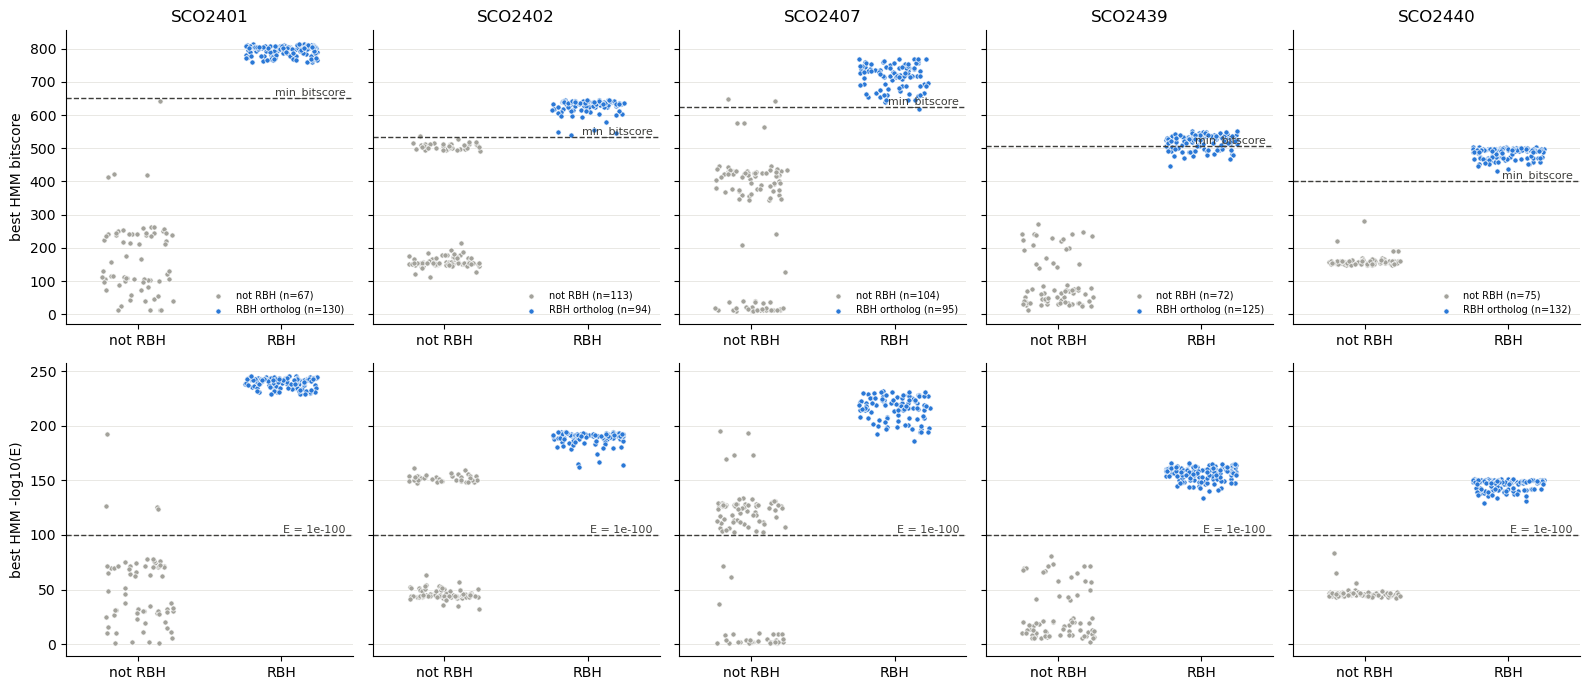

In [7]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, len(GENES), figsize=(3.2 * len(GENES), 7), sharey="row")

for j, gene in enumerate(GENES):
    sub = calls[(calls.gene == gene) & calls.hmm_best_bitscore.notna()]
    for i, (col, line, label) in enumerate([
        ("hmm_best_bitscore", MIN_BITSCORE.get(gene), "min_bitscore"),
        ("hmm_best_neglog10_e", -np.log10(E_CUTOFF), f"E = {E_CUTOFF:g}"),
    ]):
        ax = axes[i, j]
        for is_rbh, color, name, x0 in [(False, C_NOT_RBH, "not RBH", 0), (True, C_RBH, "RBH ortholog", 1)]:
            y = sub.loc[sub.rbh == is_rbh, col]
            ax.scatter(x0 + rng.uniform(-0.25, 0.25, len(y)), y, s=14, color=color,
                       edgecolor="white", linewidth=0.5, label=f"{name} (n={len(y)})")
        if line is not None and not np.isnan(line):
            ax.axhline(line, color="#3d3d3a", linestyle="--", linewidth=1)
            ax.text(1.45, line, label, fontsize=8, va="bottom", ha="right", color="#3d3d3a")
        ax.set_xticks([0, 1], ["not RBH", "RBH"])
        ax.set_xlim(-0.5, 1.5)
        ax.grid(axis="y", color="#e5e4df", linewidth=0.6)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        if i == 0:
            ax.set_title(gene)
    axes[0, j].legend(fontsize=7, loc="lower right", frameon=False)

axes[0, 0].set_ylabel("best HMM bitscore")
axes[1, 0].set_ylabel("best HMM -log10(E)")
fig.tight_layout()
plt.show()